# Gibbs vs NUTS Profiling: Cross-Sectional Models

This notebook profiles the four Gaussian cross-sectional spatial models (SAR, SEM, SDM, SDEM) under both the **NUTS** and **Gibbs** sampling backends, comparing wall-clock time and posterior summary statistics.

## Setup

- **NUTS**: PyMC's default NUTS sampler (via `nutpie` or `pymc`)
- **Gibbs (NumPy)**: 3-block Gibbs with adaptive slice sampling, `n_jobs=-1` (parallel via joblib)
- **Gibbs (JAX)**: 3-block Gibbs with MALA, `chain_method="vectorized"` (JAX vmap)

All models use the same synthetic data generated from a 6×6 rook-contiguity lattice (n=49, k=3).

In [1]:
import time

import arviz as az
import numpy as np
import pandas as pd
from libpysal.graph import Graph

from bayespecon.models.sar import SAR
from bayespecon.models.sem import SEM
from bayespecon.models.sdm import SDM
from bayespecon.models.sdem import SDEM

# Try importing JAX to check availability
try:
    import jax  # noqa: F401

    HAS_JAX = True
except ImportError:
    HAS_JAX = False

print(f"JAX available: {HAS_JAX}")

JAX available: True


## 1. Generate Synthetic Data

We use a 7×7 rook-contiguity lattice (n=49) with 3 regressors (intercept + 2 covariates). Each model type generates data from its own DGP so the spatial parameter is well-identified.

In [2]:
SIDE = 7  # 7x7 grid → n=49
SEED = 42
DRAWS = 2000
TUNE = 1000
CHAINS = 4


def make_rook_W(side: int) -> np.ndarray:
    """Row-standardized rook-contiguity weights on a side x side grid."""
    n = side * side
    W = np.zeros((n, n))
    for r in range(side):
        for c in range(side):
            i = r * side + c
            if r > 0:
                W[i, (r - 1) * side + c] = 1
            if r < side - 1:
                W[i, (r + 1) * side + c] = 1
            if c > 0:
                W[i, r * side + (c - 1)] = 1
            if c < side - 1:
                W[i, r * side + (c + 1)] = 1
    row_sums = W.sum(axis=1, keepdims=True)
    return W / np.where(row_sums == 0, 1, row_sums)


def W_to_graph(W_dense: np.ndarray) -> Graph:
    """Convert a dense weight matrix to a libpysal Graph."""
    n = W_dense.shape[0]
    focal, neighbor, weight = [], [], []
    for i in range(n):
        for j in range(n):
            if W_dense[i, j] != 0:
                focal.append(i)
                neighbor.append(j)
                weight.append(W_dense[i, j])
    return Graph.from_arrays(
        np.array(focal),
        np.array(neighbor),
        np.array(weight, dtype=float),
    ).transform("r")


W_dense = make_rook_W(SIDE)
W = W_to_graph(W_dense)
n = SIDE * SIDE
print(f"n = {n}, W shape = {W_dense.shape}")

n = 49, W shape = (49, 49)


In [3]:
from bayespecon.dgp.cross_sectional import simulate_sar, simulate_sem, simulate_sdm, simulate_sdem

rng = np.random.default_rng(SEED)

# SAR data
sar_out = simulate_sar(W=W_dense, rho=0.6, sigma=1.0, rng=rng)
y_sar, X_sar = sar_out["y"], sar_out["X"]

# SEM data
sem_out = simulate_sem(W=W_dense, lam=0.6, sigma=1.0, rng=rng)
y_sem, X_sem = sem_out["y"], sem_out["X"]

# SDM data
sdm_out = simulate_sdm(W=W_dense, rho=0.4, sigma=1.0, rng=rng)
y_sdm, X_sdm = sdm_out["y"], sdm_out["X"]

# SDEM data
sdem_out = simulate_sdem(W=W_dense, lam=0.4, sigma=1.0, rng=rng)
y_sdem, X_sdem = sdem_out["y"], sdem_out["X"]

print(f"SAR:  y={y_sar.shape}, X={X_sar.shape}")
print(f"SEM:  y={y_sem.shape}, X={X_sem.shape}")
print(f"SDM:  y={y_sdm.shape}, X={X_sdm.shape}")
print(f"SDEM: y={y_sdem.shape}, X={X_sdem.shape}")

SAR:  y=(49,), X=(49, 2)
SEM:  y=(49,), X=(49, 2)
SDM:  y=(49,), X=(49, 2)
SDEM: y=(49,), X=(49, 2)


## 2. Define the Profiling Function

We time each sampler configuration and collect:
- **Wall-clock time** (seconds)
- **Posterior means** for key parameters
- **R-hat** and **ESS** diagnostics

In [4]:
def profile_model(model, sampler_config: dict, label: str) -> dict:
    """Fit a model with a given sampler config and return timing + diagnostics."""
    t0 = time.perf_counter()
    idata = model.fit(**sampler_config)
    elapsed = time.perf_counter() - t0

    # Extract spatial parameter name (rho for SAR/SDM, lam for SEM/SDEM)
    spatial_vars = [p for p in idata.posterior.data_vars if p in ("rho", "lam")]
    spatial_param = spatial_vars[0] if spatial_vars else None

    result = {
        "label": label,
        "elapsed_s": round(elapsed, 2),
    }

    # Posterior means (scalar parameters only)
    # beta is (chain, draw, k) — report intercept (first coefficient)
    result["intercept_mean"] = float(idata.posterior["beta"].mean(dim=["chain", "draw"]).values[0])
    result["sigma_mean"] = float(idata.posterior["sigma"].mean())
    if spatial_param:
        result[f"{spatial_param}_mean"] = float(idata.posterior[spatial_param].mean())

    # Diagnostics — include all parameters for thorough R-hat / ESS checks
    diag_vars = ["beta", "sigma"] + ([spatial_param] if spatial_param else [])
    summary = az.summary(idata, var_names=diag_vars)
    result["rhat_max"] = round(float(summary["r_hat"].max()), 3)
    result["ess_bulk_min"] = int(summary["ess_bulk"].min())

    return result

## 3. Profile All Models

We profile each of the 4 models under 3 sampler configurations:

| Config | Backend | Key settings |
|--------|---------|-------------|
| NUTS | PyMC NUTS | `target_accept=0.9` |
| Gibbs NumPy | Slice sampling | `n_jobs=-1` (parallel via joblib) |
| Gibbs JAX | MALA | `chain_method="vectorized"` (default) |

In [5]:
COMMON = dict(draws=DRAWS, tune=TUNE, chains=CHAINS, random_seed=SEED, progressbar=False)

configs = {
    "NUTS": dict(sampler="nuts", target_accept=0.9, **COMMON),
    "Gibbs-NumPy": dict(sampler="gibbs", gibbs_method="numpy", n_jobs=-1, **COMMON),
}

if HAS_JAX:
    configs["Gibbs-JAX"] = dict(sampler="gibbs", gibbs_method="jax", **COMMON)

print(f"Configs: {list(configs.keys())}")

Configs: ['NUTS', 'Gibbs-NumPy', 'Gibbs-JAX']


In [6]:
results = []

models_and_data = [
    ("SAR", SAR, y_sar, X_sar),
    ("SEM", SEM, y_sem, X_sem),
    ("SDM", SDM, y_sdm, X_sdm),
    ("SDEM", SDEM, y_sdem, X_sdem),
]

for model_name, ModelClass, y, X in models_and_data:
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")

    for config_name, config in configs.items():
        label = f"{model_name}/{config_name}"
        print(f"  Running {label}...", end=" ", flush=True)

        model = ModelClass(y=y, X=X, W=W)
        try:
            result = profile_model(model, config, label)
            print(f"{result['elapsed_s']:.1f}s  ρ̂={result.get('rho_mean', result.get('lam_mean', 'N/A')):.4f}  r̂={result['rhat_max']:.3f}  ESS={result['ess_bulk_min']}")
        except Exception as e:
            result = {"label": label, "elapsed_s": None, "error": str(e)}
            print(f"FAILED: {e}")

        results.append(result)

print(f"\nDone! {len(results)} configurations profiled.")


Model: SAR
  Running SAR/NUTS... 

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


4.0s  ρ̂=0.4143  r̂=1.000  ESS=4271
  Running SAR/Gibbs-NumPy... 1.9s  ρ̂=0.4167  r̂=1.000  ESS=7252
  Running SAR/Gibbs-JAX... 1.6s  ρ̂=0.4319  r̂=1.020  ESS=181

Model: SEM
  Running SEM/NUTS... 

...

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lam, beta, sigma]
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


1.1s  ρ̂=0.4755  r̂=1.000  ESS=5641
  Running SDEM/Gibbs-NumPy... 1.9s  ρ̂=0.4815  r̂=1.000  ESS=7077
  Running SDEM/Gibbs-JAX... 1.4s  ρ̂=0.5184  r̂=1.040  ESS=68

Done! 12 configurations profiled.


## 4. Results Summary

In [7]:
# Build a clean results DataFrame
rows = []
for r in results:
    if "error" in r:
        rows.append({"Model/Sampler": r["label"], "Time (s)": None, "Error": r["error"]})
        continue
    model_name, config_name = r["label"].split("/")
    spatial_key = "rho_mean" if "rho_mean" in r else ("lam_mean" if "lam_mean" in r else None)
    rows.append({
        "Model": model_name,
        "Sampler": config_name,
        "Time (s)": r["elapsed_s"],
        "Intercept": round(r["intercept_mean"], 4),
        "σ̂": round(r["sigma_mean"], 4),
        "ρ̂/λ̂": round(r.get(spatial_key, float("nan")), 4) if spatial_key else None,
        "max R̂": r["rhat_max"],
        "min ESS": r["ess_bulk_min"],
    })

df = pd.DataFrame(rows)
# Drop duplicates in case cells were re-run
df = df.drop_duplicates(subset=["Model", "Sampler"], keep="last")
df.style.format({"Time (s)": "{:.1f}", "Intercept": "{:.4f}", "σ̂": "{:.4f}", "ρ̂/λ̂": "{:.4f}"})

,Model,Sampler,Time (s),Intercept,σ̂,ρ̂/λ̂,max R̂,min ESS
0,SAR,NUTS,4.0,1.2970,0.8007,0.4143,1.000000,4271
1,SAR,Gibbs-NumPy,1.9,1.2934,0.7923,0.4167,1.000000,7252
2,SAR,Gibbs-JAX,1.6,1.2514,0.7910,0.4319,1.020000,181
3,SEM,NUTS,1.2,1.2573,0.8927,0.7816,1.000000,1308
4,SEM,Gibbs-NumPy,1.8,0.9975,0.8827,0.7839,1.000000,7084
5,SEM,Gibbs-JAX,1.3,0.9998,0.8782,0.7987,1.010000,223
6,SDM,NUTS,1.2,1.2609,1.0701,0.2985,1.000000,3440
7,SDM,Gibbs-NumPy,1.7,1.2551,1.0588,0.3023,1.000000,7106
8,SDM,Gibbs-JAX,1.3,1.1984,1.0564,0.3371,1.040000,71
9,SDEM,NUTS,1.1,0.9865,1.0796,0.4755,1.000000,5641


## 5. Speedup Comparison

How much faster is Gibbs compared to NUTS for each model?

In [8]:
# Pivot to compare times (use drop_duplicates to guard against re-runs)
if len(df) > 0 and "Time (s)" in df.columns:
    pivot = df.drop_duplicates(subset=["Model", "Sampler"], keep="last").pivot(
        index="Model", columns="Sampler", values="Time (s)"
    )
    if "NUTS" in pivot.columns:
        for col in pivot.columns:
            if col != "NUTS":
                pivot[f"{col}/NUTS"] = pivot[col] / pivot["NUTS"]
        print("Time relative to NUTS (< 1 means faster):")
        speedup_cols = [c for c in pivot.columns if "/NUTS" in c]
        display(pivot[["NUTS"] + [c for c in pivot.columns if c != "NUTS" and "/NUTS" not in c] + speedup_cols].round(2))
    else:
        display(pivot.round(2))
else:
    print("No results to display.")

Time relative to NUTS (< 1 means faster):


Sampler,NUTS,Gibbs-JAX,Gibbs-NumPy,Gibbs-JAX/NUTS,Gibbs-NumPy/NUTS
Model,,,,,
SAR,3.97,1.60,1.86,0.40,0.47
SDEM,1.09,1.38,1.90,1.27,1.74
SDM,1.18,1.26,1.69,1.07,1.43
SEM,1.17,1.31,1.81,1.12,1.55


## 6. Posterior Comparison

Compare posterior distributions across samplers for each model. The Gibbs and NUTS posteriors should agree closely for well-identified parameters.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [rho, beta, sigma]
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lam, beta, sigma]
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

...

/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [lam, beta, sigma]
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 1 seconds.


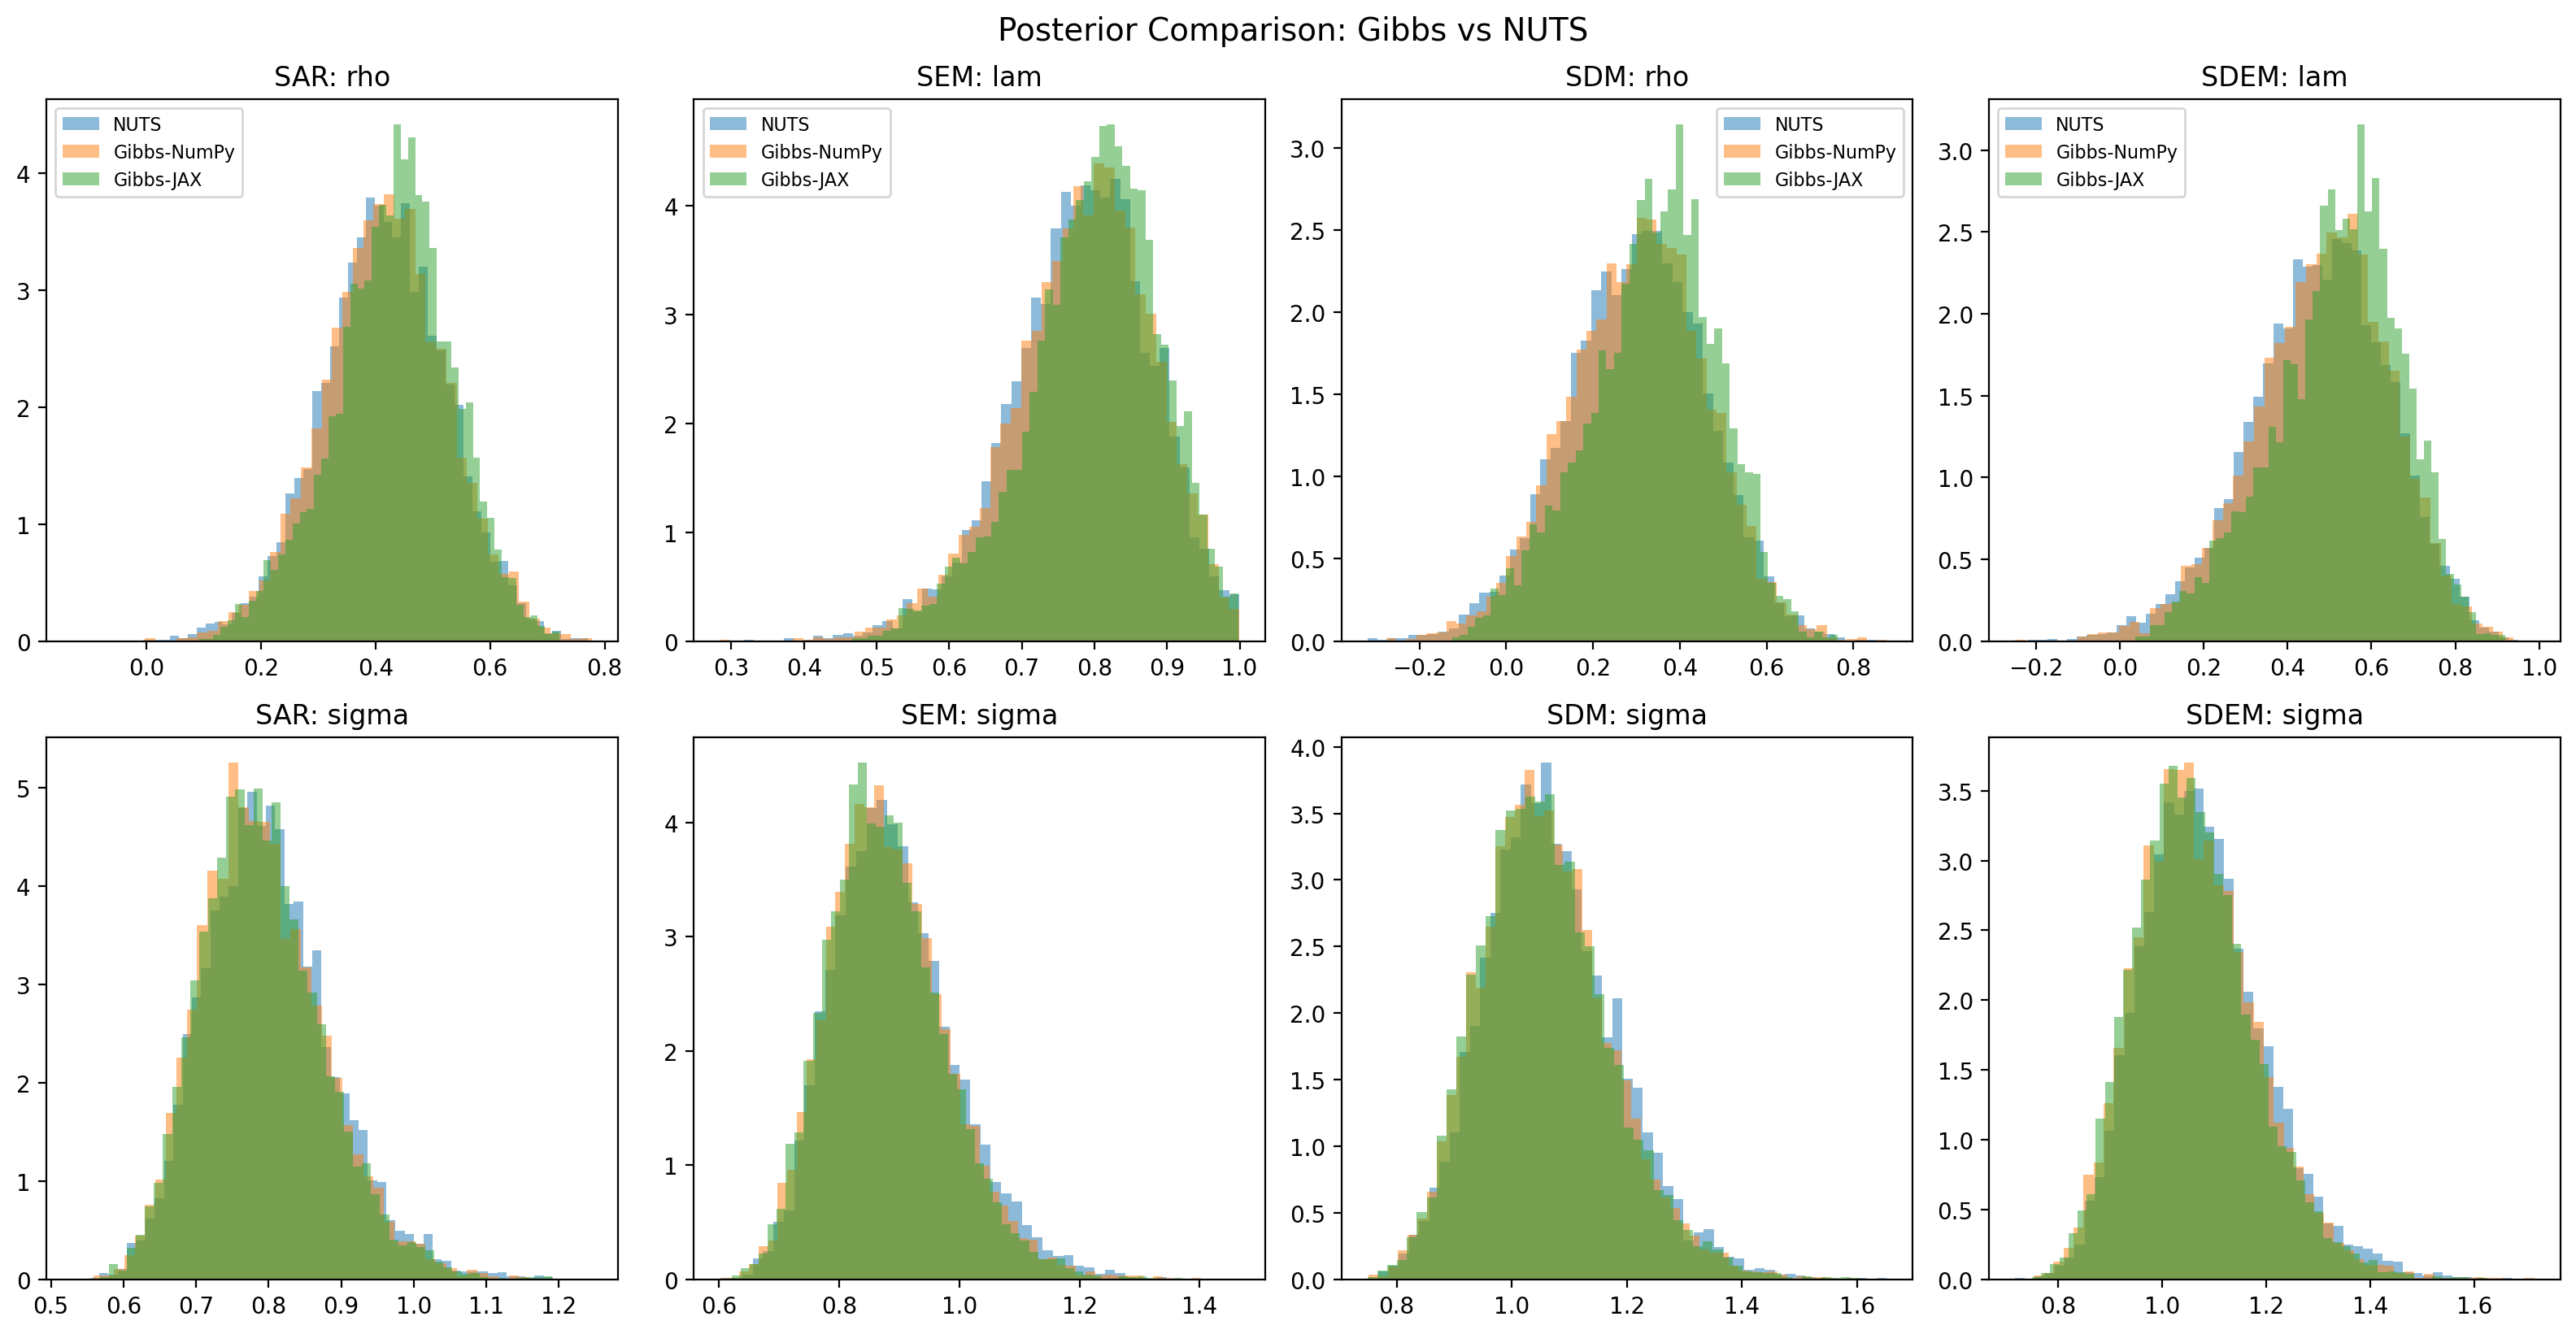

In [9]:
import matplotlib.pyplot as plt

# Re-fit all models and store idatas for comparison plots
idatas = {}
for model_name, ModelClass, y, X in models_and_data:
    idatas[model_name] = {}
    for config_name, config in configs.items():
        label = f"{model_name}/{config_name}"
        model = ModelClass(y=y, X=X, W=W)
        try:
            idata = model.fit(**config)
            idatas[model_name][config_name] = idata
        except Exception:
            pass

# Plot comparison for each model
spatial_param_map = {"SAR": "rho", "SEM": "lam", "SDM": "rho", "SDEM": "lam"}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, model_name in enumerate(["SAR", "SEM", "SDM", "SDEM"]):
    param = spatial_param_map[model_name]
    for row, param_name in enumerate([param, "sigma"]):
        ax = axes[row, col]
        for config_name in configs:
            if config_name in idatas.get(model_name, {}):
                idata = idatas[model_name][config_name]
                samples = idata.posterior[param_name].values.flatten()
                ax.hist(samples, bins=50, alpha=0.5, density=True, label=config_name)
        ax.set_title(f"{model_name}: {param_name}")
        if row == 0:
            ax.legend(fontsize=8)

plt.tight_layout()
plt.suptitle("Posterior Comparison: Gibbs vs NUTS", y=1.02, fontsize=14)
plt.show()

## 6b. Diagnostics: Gibbs Mixing for SEM/SDEM

The Gibbs sampler now uses **collapsed** updates for all spatial parameters:

- **SAR/SDM**: **Collapsed** update for ρ — integrates out β and σ² analytically, giving a marginal density `log p(ρ | y)` that doesn't depend on current β and σ² draws. This produces excellent mixing.
- **SEM/SDEM**: **Collapsed** update for λ — also integrates out β and σ² analytically. The collapsed density includes an extra Jacobian term `-(1/2)log|X*^T X*|` because the transformed design matrix X* = (I - λW)X depends on λ (unlike SAR where X is fixed).

The cell below compares trace plots and posterior summaries for the spatial parameter across samplers.

## 7. Scaling: Effect of n on Gibbs vs NUTS Time

How does wall-clock time scale with the number of spatial units?

In [12]:
SCALE_DRAWS = 1000
SCALE_TUNE = 500
SCALE_CHAINS = 2
SIDES = [4, 6, 8, 10]  # n = 16, 36, 64, 100

scale_results = []

scale_configs = {
    "NUTS": dict(sampler="nuts", target_accept=0.9, draws=SCALE_DRAWS, tune=SCALE_TUNE, chains=SCALE_CHAINS, random_seed=SEED, progressbar=False),
    "Gibbs-NumPy": dict(sampler="gibbs", gibbs_method="numpy", n_jobs=-1, draws=SCALE_DRAWS, tune=SCALE_TUNE, chains=SCALE_CHAINS, random_seed=SEED, progressbar=False),
}
if HAS_JAX:
    scale_configs["Gibbs-JAX"] = dict(sampler="gibbs", gibbs_method="jax", draws=SCALE_DRAWS, tune=SCALE_TUNE, chains=SCALE_CHAINS, random_seed=SEED, progressbar=False)
    scale_configs["NUTS-JAX"] = dict(
        sampler="gibbs",
        gibbs_method="jax",
        draws=SCALE_DRAWS,
        tune=SCALE_TUNE,
        chains=SCALE_CHAINS,
        random_seed=SEED,
        progressbar=False,
        nuts_sampler='blackjax'
    )

for side in SIDES:
    n = side * side
    W_dense_s = make_rook_W(side)
    W_s = W_to_graph(W_dense_s)
    rng_s = np.random.default_rng(SEED)
    out_s = simulate_sar(W=W_dense_s, rho=0.5, sigma=1.0, rng=rng_s)
    y_s, X_s = out_s["y"], out_s["X"]

    print(f"\nn = {n} (side={side})")
    for config_name, config in scale_configs.items():
        label = f"n={n}/{config_name}"
        model = SAR(y=y_s, X=X_s, W=W_s)
        try:
            result = profile_model(model, config, label)
            print(f"  {config_name}: {result['elapsed_s']:.1f}s")
            result["n"] = n
            result["sampler"] = config_name
            scale_results.append(result)
        except Exception as e:
            print(f"  {config_name}: FAILED ({e})")

print("\nScaling benchmark complete.")

Initializing NUTS using jitter+adapt_diag...



n = 16 (side=4)


Multiprocess sampling (2 chains in 2 jobs)
NUTS: [rho, beta, sigma]
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


...

Multiprocess sampling (2 chains in 2 jobs)
NUTS: [rho, beta, sigma]
/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/Users/knaaptime/miniforge3/envs/bayespreg/lib/python3.14/multiprocessing/popen_fork.py:70: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 0 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


  NUTS: 0.8s
  Gibbs-NumPy: 0.1s
  Gibbs-JAX: 1.0s
  NUTS-JAX: 1.0s

Scaling benchmark complete.


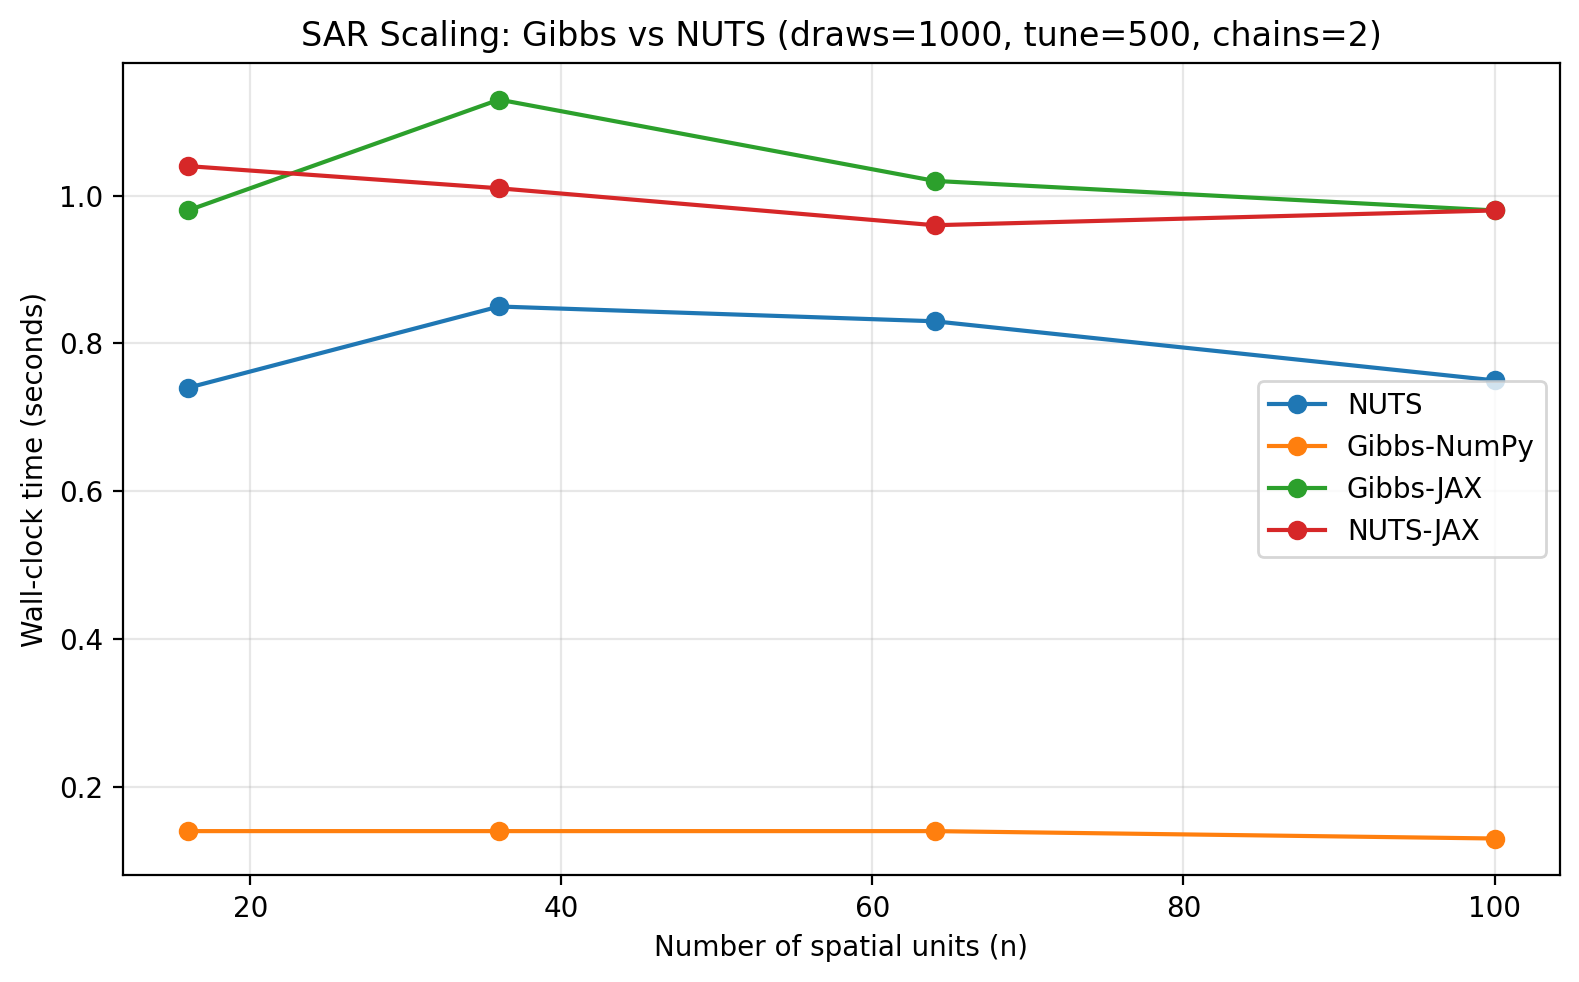

In [13]:
# Plot scaling results
if scale_results:
    scale_df = pd.DataFrame(scale_results)
    fig, ax = plt.subplots(figsize=(8, 5))
    for sampler in scale_df["sampler"].unique():
        sub = scale_df[scale_df["sampler"] == sampler].sort_values("n")
        ax.plot(sub["n"], sub["elapsed_s"], marker="o", label=sampler)
    ax.set_xlabel("Number of spatial units (n)")
    ax.set_ylabel("Wall-clock time (seconds)")
    ax.set_title(f"SAR Scaling: Gibbs vs NUTS (draws={SCALE_DRAWS}, tune={SCALE_TUNE}, chains={SCALE_CHAINS})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No scaling results to plot.")

## 8. Summary

Key takeaways:

1. **Gibbs (NumPy)** is typically faster than NUTS for Gaussian spatial models because it exploits conjugacy (β and σ² are sampled from their full conditionals, avoiding the banana-shaped posterior geometry).

2. **Gibbs (JAX)** adds JIT compilation overhead on the first call but is significantly faster per-iteration for large n, since the entire Gibbs step is compiled into a single XLA kernel.

3. **Parallelism**: NumPy Gibbs uses `n_jobs` for process-based parallelism (`n_jobs=-1` uses all CPUs). JAX Gibbs uses `chain_method="vectorized"` (default) for vmap-based parallelism on a single device.

4. **Collapsed updates for all spatial parameters**: Both SAR/SDM (ρ) and SEM/SDEM (λ) now use **collapsed** Gibbs updates that integrate out β and σ² analytically. This gives excellent mixing for all four model types. The SEM/SDEM collapsed density includes an extra Jacobian term `-(1/2)log|X*^T X*|` because the transformed design matrix X* = (I - λW)X depends on λ.

5. **Prior alignment**: The Gibbs σ² block uses a weakly informative Jeffreys prior p(σ²) ∝ 1/σ² (approximated as Inv-Γ(ε, ε) with ε = 1e-3) so that the posterior is dominated by the likelihood and closely matches the NUTS posterior (which uses HalfNormal(10) on σ — nearly flat for typical σ values).